# Modulo 2: Supervised Learning e Ottimizzazione
## Predizione del PEGI dei Videogiochi di Steam

### Flusso del progetto:
1. **Feature Engineering** – Caricamento dati, encoding tag, mappatura PEGI
2. **Setup** – Installazione librerie, feature selection, validazione cross-fold
3. **Ottimizzazione XGBoost** – Hyperparameter tuning con Optuna (30 trial)
4. **Ottimizzazione LightGBM** – Hyperparameter tuning con Optuna (20 trial)
5. **Ensemble Stacking** – 4 base learner + meta-learner LogisticRegression
6. **Valutazione Finale** – Metriche, confusion matrix, ROC curve, SHAP values

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MultiLabelBinarizer
import ast
import warnings
warnings.filterwarnings('ignore')

print('[INFO] Sezione 1: Feature Engineering')
print('=' * 70)

[INFO] Sezione 1: Feature Engineering


## Sezione 1: Feature Engineering e Caricamento Dati

In [2]:
# Caricamento dataset (supporto locale e Colab)
csv_path = None
for candidate in ['/content/for_EDA.csv', 'for_EDA.csv']:
    if os.path.exists(candidate):
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError('[ERROR] for_EDA.csv non trovato!')

df = pd.read_csv(csv_path)
print(f'[INFO] Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne')
print(f'[INFO] Colonne: {list(df.columns[:10])}...')


[INFO] Dataset caricato: 103976 righe × 21 colonne
[INFO] Colonne: ['title', 'developer', 'publisher', 'overall_reviews', 'tags', 'genre', 'ram', 'year', 'month', 'user_rating_all']...


In [3]:
# Ispeziona struttura del dataset
print('[INFO] Struttura del dataset for_EDA.csv:')
print(f'\nColonne disponibili ({len(df.columns)}):')
print(df.columns.tolist())
print(f'\nTipi di dati:')
print(df.dtypes)
print(f'\nPrime righe:')
df.head()

[INFO] Struttura del dataset for_EDA.csv:

Colonne disponibili (21):
['title', 'developer', 'publisher', 'overall_reviews', 'tags', 'genre', 'ram', 'year', 'month', 'user_rating_all', 'total_review_all', 'user_rating_recent', 'total_review_recent', 'supported_language', 'price', 'pegi_rated', 'age_rating', 'windows', 'mac', 'linux', 'VR']

Tipi di dati:
title                   object
developer               object
publisher               object
overall_reviews         object
tags                    object
genre                   object
ram                     object
year                   float64
month                   object
user_rating_all        float64
total_review_all       float64
user_rating_recent     float64
total_review_recent    float64
supported_language     float64
price                  float64
pegi_rated               int64
age_rating             float64
windows                  int64
mac                      int64
linux                    int64
VR                      

,title,developer,publisher,overall_reviews,tags,genre,ram,year,month,user_rating_all,...,user_rating_recent,total_review_recent,supported_language,price,pegi_rated,age_rating,windows,mac,linux,VR
0,Apex Legends™,['Respawn Entertainment'],['Electronic Arts'],Very Positive,"['Free to Play', 'Battle Royale', 'Multiplayer...","['Action', 'Adventure', 'Free to Play']",6 GB,2020.0,Nov,86.0,...,81.0,15998.0,13.0,0.0,0,16.0,1,0,0,0
1,God of War,['Santa Monica Studio'],['PlayStation PC LLC'],Overwhelmingly Positive,"['Action', 'Adventure', 'Singleplayer', 'Story...","['Action', 'Adventure', 'RPG']",8 GB,2022.0,Jan,97.0,...,96.0,1056.0,18.0,729000.0,0,18.0,1,0,0,0
2,ELDEN RING,['FromSoftware Inc.'],"['FromSoftware Inc.', 'Bandai Namco Entertainm...",Very Positive,"['Souls-like', 'Relaxing', 'Dark Fantasy', 'RP...","['Action', 'RPG']",2 GB,2022.0,Feb,90.0,...,92.0,14027.0,14.0,599000.0,0,16.0,1,0,0,0
3,Grand Theft Auto V,['Rockstar North'],['Rockstar Games'],Very Positive,"['Open World', 'Action', 'Multiplayer', 'Autom...","['Action', 'Adventure']",4 GB,2015.0,Apr,85.0,...,90.0,15021.0,13.0,NaN,0,18.0,1,0,0,0
4,Forza Horizon 5,['Playground Games'],['Xbox Game Studios'],Very Positive,"['Racing', 'Open World', 'Driving', 'Multiplay...","['Action', 'Adventure', 'Racing', 'Simulation'...",8 GB,2021.0,Nov,87.0,...,88.0,3005.0,16.0,699000.0,0,NaN,1,0,0,0


In [4]:
# Multi-Hot Encoding sui tag (se la colonna 'tags' esiste)
if 'tags' in df.columns:
    def clean_tags(t):
        if pd.isna(t) or not isinstance(t, str):
            return []
        t = t.strip()
        if t.startswith('[') and t.endswith(']'):
            try:
                return ast.literal_eval(t)
            except (ValueError, SyntaxError):
                pass
        return [x.strip() for x in t.split(',') if x.strip()]

    df['tags_cleaned'] = df['tags'].apply(clean_tags)
    mlb = MultiLabelBinarizer()
    tags_enc = mlb.fit_transform(df['tags_cleaned'])
    tags_cols = [f"Tag_{g.replace(' ','_').replace('-','_').replace('/','_')}" for g in mlb.classes_]
    tags_df = pd.DataFrame(tags_enc, columns=tags_cols, index=df.index)
    df_encoded = tags_df.copy()

    print(f'[INFO] Tag unici codificati: {len(mlb.classes_)}')
else:
    print('[INFO] Colonna "tags" non trovata, impossibile eseguire il training basato solo sui tag.')
    raise ValueError('Impossibile trovare colonna tags')

print(f'[INFO] Shape dopo multi-hot encoding tag: {df_encoded.shape}')

[INFO] Tag unici codificati: 430
[INFO] Shape dopo multi-hot encoding tag: (103976, 430)


In [5]:
# Mappatura target PEGI → classi [0-4]
# Cerca colonna target (pegi, required_age, age_rating, etc.) nel dataframe originale
pegi_col = None
for candidate in ['pegi', 'required_age', 'age_rating', 'rating']:
    if candidate in df.columns:
        pegi_col = candidate
        break

if pegi_col is None:
    print('[WARNING] Nessuna colonna PEGI trovata!')
    print(f'Colonne disponibili: {df.columns.tolist()}')
    raise ValueError('Impossibile trovare colonna target per PEGI')

pegi_mapping = {3: 0, 7: 1, 12: 2, 16: 3, 18: 4}

df_encoded['target_class'] = df[pegi_col].map(pegi_mapping)
df_encoded = df_encoded.dropna(subset=['target_class']).copy()
df_encoded['target_class'] = df_encoded['target_class'].astype(int)
df_final = df_encoded

print(f'[INFO] Colonna target utilizzata: "{pegi_col}"')
print('[INFO] Distribuzione classi target:')
for pv, ci in sorted(pegi_mapping.items()):
    count = (df_final['target_class'] == ci).sum()
    pct = count / len(df_final) * 100 if len(df_final) > 0 else 0
    print(f'   PEGI {pv} (Classe {ci}): {count:5d} campioni ({pct:5.1f}%)')

print(f'\n[INFO] Shape dataset finale: {df_final.shape}')

[INFO] Colonna target utilizzata: "age_rating"
[INFO] Distribuzione classi target:
   PEGI 3 (Classe 0):  3954 campioni ( 23.9%)
   PEGI 7 (Classe 1):  1923 campioni ( 11.6%)
   PEGI 12 (Classe 2):  5191 campioni ( 31.4%)
   PEGI 16 (Classe 3):  3164 campioni ( 19.1%)
   PEGI 18 (Classe 4):  2292 campioni ( 13.9%)

[INFO] Shape dataset finale: (16524, 431)


## Sezione 2: Setup – Installazione librerie e Feature Selection

In [6]:
!pip install -q optuna xgboost lightgbm catboost imbalanced-learn shap scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


In [7]:
import joblib
import optuna
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score
from imblearn.over_sampling import BorderlineSMOTE

optuna.logging.set_verbosity(optuna.logging.WARNING)

print('[INFO] Sezione 2: Setup e configurazione')
print('=' * 70)


[INFO] Sezione 2: Setup e configurazione


In [8]:
# Suddivisione features tags e target
X = df_final.drop(columns=['target_class'])
y = df_final['target_class'].values

# I tag sono già codificati come colonne binarie
X_tags = X.fillna(0).astype(int)

print(f'[INFO] Shape X tags: {X_tags.shape} | Shape y: {y.shape}')

# Feature Selection con Mutual Information (solo sui tag)
K_FEATURES = min(200, X_tags.shape[1])
print(f'[INFO] Selezione top-{K_FEATURES} feature via mutual_info_classif...')

selector = SelectKBest(score_func=mutual_info_classif, k=K_FEATURES)
X_sel_arr = selector.fit_transform(X_tags, y)
sel_names = X_tags.columns[selector.get_support()].tolist()
X_sel = pd.DataFrame(X_sel_arr, columns=sel_names)

print(f'[INFO] Feature selezionate: {X_sel.shape[1]}')
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(sel_names, 'selected_features.pkl')

[INFO] Shape X tags: (16524, 430) | Shape y: (16524,)
[INFO] Selezione top-200 feature via mutual_info_classif...
[INFO] Feature selezionate: 200


['selected_features.pkl']

In [9]:
# Configurazione validazione e bilanciamento
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
smt = BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')

print(f'[INFO] StratifiedKFold: {N_SPLITS} fold')
print(f'[INFO] Bilanciamento: BorderlineSMOTE (kind=borderline-1)')
print(f'[INFO] Setup completato!\n')


[INFO] StratifiedKFold: 5 fold
[INFO] Bilanciamento: BorderlineSMOTE (kind=borderline-1)
[INFO] Setup completato!



## Sezione 3a: Ottimizzazione XGBoost con Optuna (30 trial)

In [10]:
print('[INFO] Sezione 3a: Ottimizzazione XGBoost')
print('=' * 70)

def objective_xgb(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 5,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1,
        # Struttura alberi
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        # Learning
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        # Campionamento stocastico
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        # Regolarizzazione
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    fold_scores = []
    for tr_idx, vl_idx in skf.split(X_sel, y):
        Xtr, Xvl = X_sel.iloc[tr_idx], X_sel.iloc[vl_idx]
        ytr, yvl = y[tr_idx], y[vl_idx]
        try:
            Xtr_r, ytr_r = smt.fit_resample(Xtr, ytr)
        except Exception:
            Xtr_r, ytr_r = Xtr, ytr

        model = xgb.XGBClassifier(**params)
        model.fit(Xtr_r, ytr_r, verbose=False)
        fold_scores.append(f1_score(yvl, model.predict(Xvl), average='macro'))

    return np.mean(fold_scores)

study_xgb = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f'\n[XGBoost] Miglior F1 Macro: {study_xgb.best_value:.4f}')
print('Migliori parametri XGBoost:')
for k, v in study_xgb.best_params.items():
    print(f'   {k}: {v}')


[INFO] Sezione 3a: Ottimizzazione XGBoost


  0%|          | 0/30 [00:00<?, ?it/s]


[XGBoost] Miglior F1 Macro: 0.6100
Migliori parametri XGBoost:
   max_depth: 9
   n_estimators: 282
   learning_rate: 0.14321082812035962
   subsample: 0.6801930803068572
   colsample_bytree: 0.9713868117527176
   colsample_bylevel: 0.740436919101005
   min_child_weight: 7
   gamma: 0.05170977806376133
   reg_alpha: 2.089504886994444e-07
   reg_lambda: 0.031683991164954815


## Sezione 3b: Ottimizzazione LightGBM con Optuna (20 trial)

In [11]:
print('\n[INFO] Sezione 3b: Ottimizzazione LightGBM')
print('=' * 70)

def objective_lgb(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 5,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    fold_scores = []
    for tr_idx, vl_idx in skf.split(X_sel, y):
        Xtr, Xvl = X_sel.iloc[tr_idx], X_sel.iloc[vl_idx]
        ytr, yvl = y[tr_idx], y[vl_idx]
        try:
            Xtr_r, ytr_r = smt.fit_resample(Xtr, ytr)
        except Exception:
            Xtr_r, ytr_r = Xtr, ytr

        model = lgb.LGBMClassifier(**params)
        model.fit(Xtr_r, ytr_r)
        fold_scores.append(f1_score(yvl, model.predict(Xvl), average='macro'))

    return np.mean(fold_scores)

study_lgb = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)

print(f'\n[LightGBM] Miglior F1 Macro: {study_lgb.best_value:.4f}')
print('Migliori parametri LightGBM:')
for k, v in study_lgb.best_params.items():
    print(f'   {k}: {v}')



[INFO] Sezione 3b: Ottimizzazione LightGBM


  0%|          | 0/20 [00:00<?, ?it/s]


[LightGBM] Miglior F1 Macro: 0.6088
Migliori parametri LightGBM:
   n_estimators: 234
   learning_rate: 0.09247592361545191
   num_leaves: 148
   max_depth: 12
   min_child_samples: 34
   subsample: 0.7325163827708847
   colsample_bytree: 0.5609202725549395
   reg_alpha: 0.05372117461481514
   reg_lambda: 1.1349117536244871e-08


## Sezione 4: Addestramento Ensemble – StackingClassifier

In [12]:
print('\n[INFO] Sezione 4: Addestramento Ensemble Stacking')
print('=' * 70)

best_xgb_p = {
    **study_xgb.best_params,
    'objective': 'multi:softprob',
    'num_class': 5,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'n_jobs': -1
}

best_lgb_p = {
    **study_lgb.best_params,
    'objective': 'multiclass',
    'num_class': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

xgb_final = xgb.XGBClassifier(**best_xgb_p)
lgb_final = lgb.LGBMClassifier(**best_lgb_p)

cat_final = CatBoostClassifier(
    loss_function='MultiClass', random_state=42,
    thread_count=-1, iterations=350, learning_rate=0.05,
    depth=7, l2_leaf_reg=3.0, verbose=0
)

et_final = ExtraTreesClassifier(
    n_estimators=300, random_state=42, n_jobs=-1,
    class_weight='balanced', max_features='sqrt'
)

print('[INFO] Base learner creati:')
print('   - XGBoost (ottimizzato)')
print('   - LightGBM (ottimizzato)')
print('   - CatBoost (iperparametri robusti)')
print('   - ExtraTrees (elevata varianza)')



[INFO] Sezione 4: Addestramento Ensemble Stacking
[INFO] Base learner creati:
   - XGBoost (ottimizzato)
   - LightGBM (ottimizzato)
   - CatBoost (iperparametri robusti)
   - ExtraTrees (elevata varianza)


In [13]:
# Meta-learner
meta_learner = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, C=1.0, multi_class='multinomial', random_state=42)
)

stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', xgb_final),
        ('lgb', lgb_final),
        ('cat', cat_final),
        ('et', et_final),
    ],
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

print('[INFO] StackingClassifier configurato (4 base + LogReg meta-learner)')

# Bilanciamento
print('[INFO] Applicando BorderlineSMOTE...')
smt_final = BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')
X_res, y_res = smt_final.fit_resample(X_sel, y)
print(f'[INFO] Bilanciamento: {X_sel.shape} → {X_res.shape}')

# Addestramento
print('[INFO] Avvio addestramento StackingClassifier...')
stacking_clf.fit(X_res, y_res)
print('[INFO] Addestramento completato!')

# Salvataggio
joblib.dump(stacking_clf, 'stacking_pegi_model.pkl')
joblib.dump(sel_names, 'model_features.pkl')
print('[INFO] Modelli salvati con successo!')


[INFO] StackingClassifier configurato (4 base + LogReg meta-learner)
[INFO] Applicando BorderlineSMOTE...
[INFO] Bilanciamento: (16524, 200) → (25955, 200)
[INFO] Avvio addestramento StackingClassifier...
[INFO] Addestramento completato!
[INFO] Modelli salvati con successo!


In [14]:
# Funzione di previsione PEGI basata sui tag inseriti
pegi_inv_map = {0: 3, 1: 7, 2: 12, 3: 16, 4: 18}

def tags_to_feature_vector(raw_tags):
    if isinstance(raw_tags, str):
        tags = clean_tags(raw_tags)
    elif isinstance(raw_tags, list):
        tags = [str(t).strip() for t in raw_tags if str(t).strip()]
    else:
        raise ValueError('I tag devono essere una stringa o una lista di tag')

    feature_dict = {name: 0 for name in sel_names}
    for tag in tags:
        feature_name = f"Tag_{tag.replace(' ','_').replace('-','_').replace('/','_')}"
        if feature_name in feature_dict:
            feature_dict[feature_name] = 1

    return pd.DataFrame([feature_dict], columns=sel_names)

def predict_pegi_from_tags(raw_tags):
    X_new = tags_to_feature_vector(raw_tags)
    proba = stacking_clf.predict_proba(X_new)[0]
    pred_class = int(proba.argmax())
    return {'predicted_class': pred_class, 'predicted_pegi': pegi_inv_map[pred_class], 'probabilities': proba}

# Esempio d'uso
example_tags = ['Action', 'Adventure', 'Multiplayer', 'Violent']
result = predict_pegi_from_tags(example_tags)
print('Esempio tags:', example_tags)
print('Predicted PEGI:', result['predicted_pegi'])
print('Probabilities:', result['probabilities'])


Esempio tags: ['Action', 'Adventure', 'Multiplayer', 'Violent']
Predicted PEGI: 18
Probabilities: [0.01565064 0.04661695 0.04034537 0.3231423  0.57424475]


## Sezione 5: Valutazione Finale e Analisi

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score, roc_auc_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import shap

print('\n[INFO] Sezione 5: Valutazione Finale')
print('=' * 70)

y_pred = stacking_clf.predict(X_sel)
y_proba = stacking_clf.predict_proba(X_sel)
pegi_labels = [f'PEGI {k}' for k in sorted(pegi_mapping.keys())]

print('\n1. CLASSIFICATION REPORT\n')
print('=' * 70)
print(classification_report(y, y_pred, target_names=pegi_labels))
print('=' * 70)



[INFO] Sezione 5: Valutazione Finale

1. CLASSIFICATION REPORT

              precision    recall  f1-score   support

      PEGI 3       0.89      0.91      0.90      3954
      PEGI 7       0.66      0.83      0.74      1923
     PEGI 12       0.94      0.73      0.82      5191
     PEGI 16       0.76      0.78      0.77      3164
     PEGI 18       0.70      0.84      0.77      2292

    accuracy                           0.81     16524
   macro avg       0.79      0.82      0.80     16524
weighted avg       0.83      0.81      0.81     16524



In [16]:
# Metriche avanzate
kappa = cohen_kappa_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)
bal_acc = balanced_accuracy_score(y, y_pred)
roc_auc = roc_auc_score(y, y_proba, multi_class='ovr', average='macro')

print('\n2. METRICHE AVANZATE\n')
print(f'  Cohen Kappa:          {kappa:.4f}')
print(f'  Matthews Corr. Coef: {mcc:.4f}')
print(f'  Balanced Accuracy:   {bal_acc:.4f}')
print(f'  Macro ROC-AUC:       {roc_auc:.4f}')



2. METRICHE AVANZATE

  Cohen Kappa:          0.7601
  Matthews Corr. Coef: 0.7635
  Balanced Accuracy:   0.8204
  Macro ROC-AUC:       0.9662



3. MATRICE DI CONFUSIONE



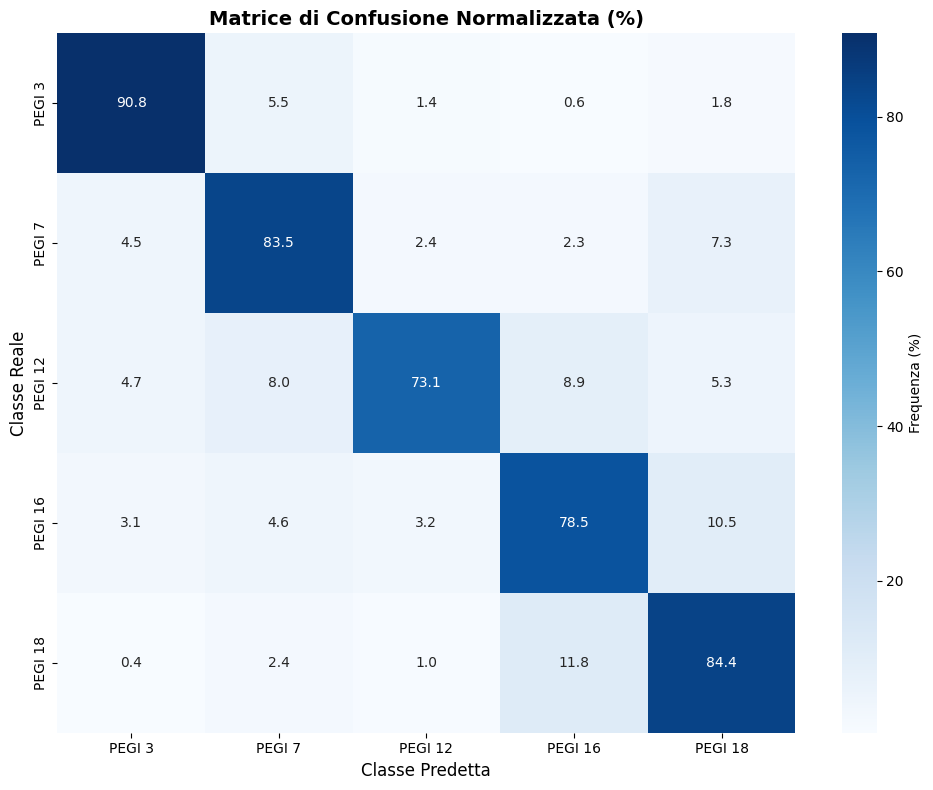

In [17]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print('\n3. MATRICE DI CONFUSIONE\n')
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=pegi_labels, yticklabels=pegi_labels,
            cbar_kws={'label': 'Frequenza (%)'})
plt.title('Matrice di Confusione Normalizzata (%)', fontsize=14, fontweight='bold')
plt.ylabel('Classe Reale', fontsize=12)
plt.xlabel('Classe Predetta', fontsize=12)
plt.tight_layout()
plt.show()



4. CURVE ROC MULTI-CLASSE



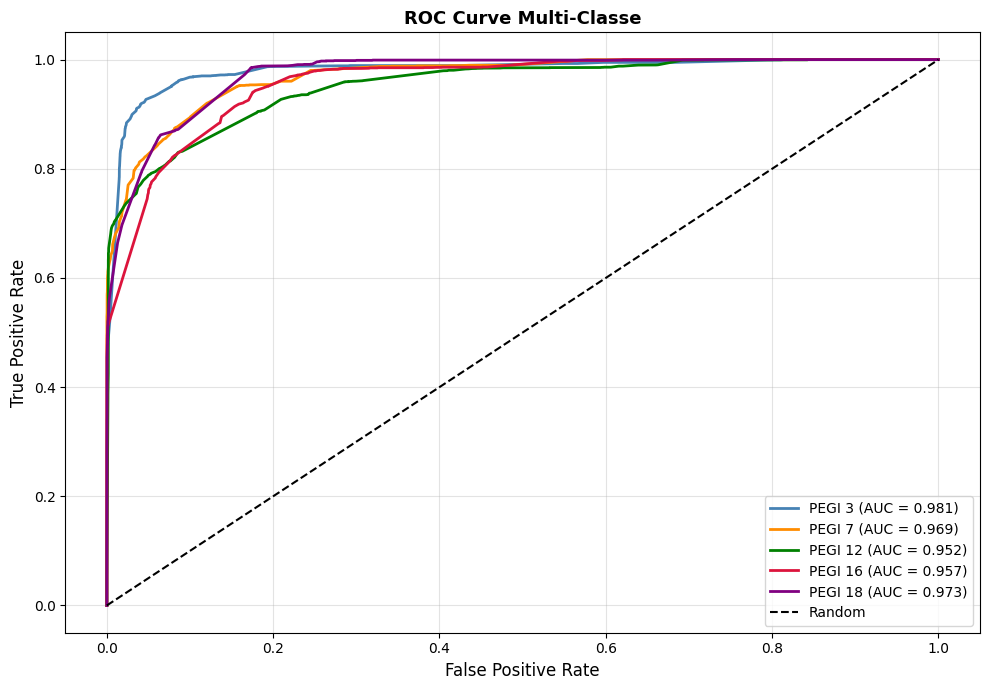

In [18]:
# ROC Curves
y_bin = label_binarize(y, classes=[0, 1, 2, 3, 4])
colors_roc = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

print('\n4. CURVE ROC MULTI-CLASSE\n')
plt.figure(figsize=(10, 7))
for i, (lab, col) in enumerate(zip(pegi_labels, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{lab} (AUC = {roc_i:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Multi-Classe', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()



5. TOP-25 FEATURE IMPORTANCE



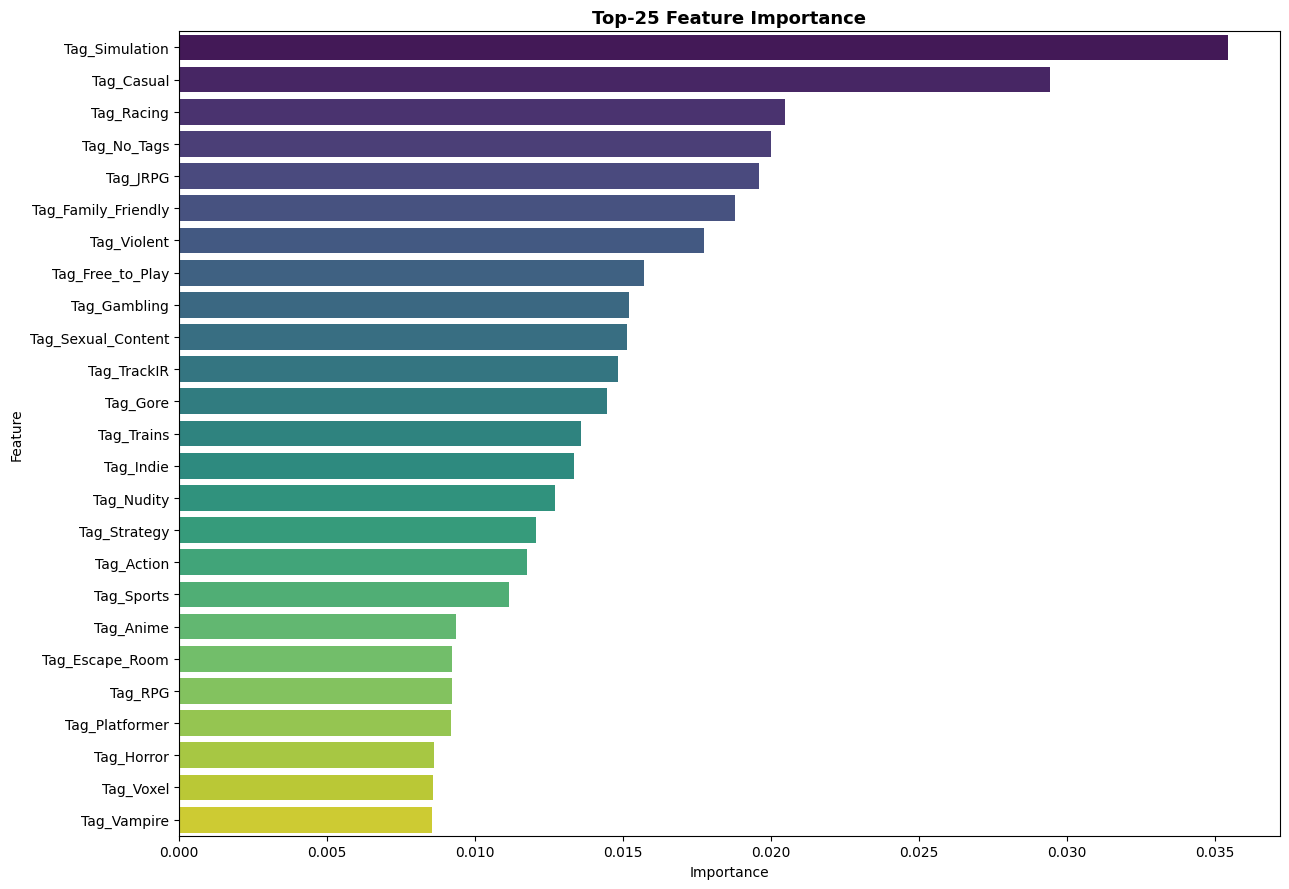

In [19]:
# Feature Importance
imp_scores = stacking_clf.named_estimators_['xgb'].feature_importances_
imp_df = pd.DataFrame({'Feature': sel_names, 'Importance': imp_scores})
imp_df = imp_df.sort_values('Importance', ascending=False)

print('\n5. TOP-25 FEATURE IMPORTANCE\n')
top_n = min(25, len(imp_df))
plt.figure(figsize=(13, 9))
sns.barplot(data=imp_df.head(top_n), x='Importance', y='Feature',
            palette='viridis', hue='Feature', legend=False)
plt.title(f'Top-{top_n} Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



6. SHAP VALUE ANALYSIS



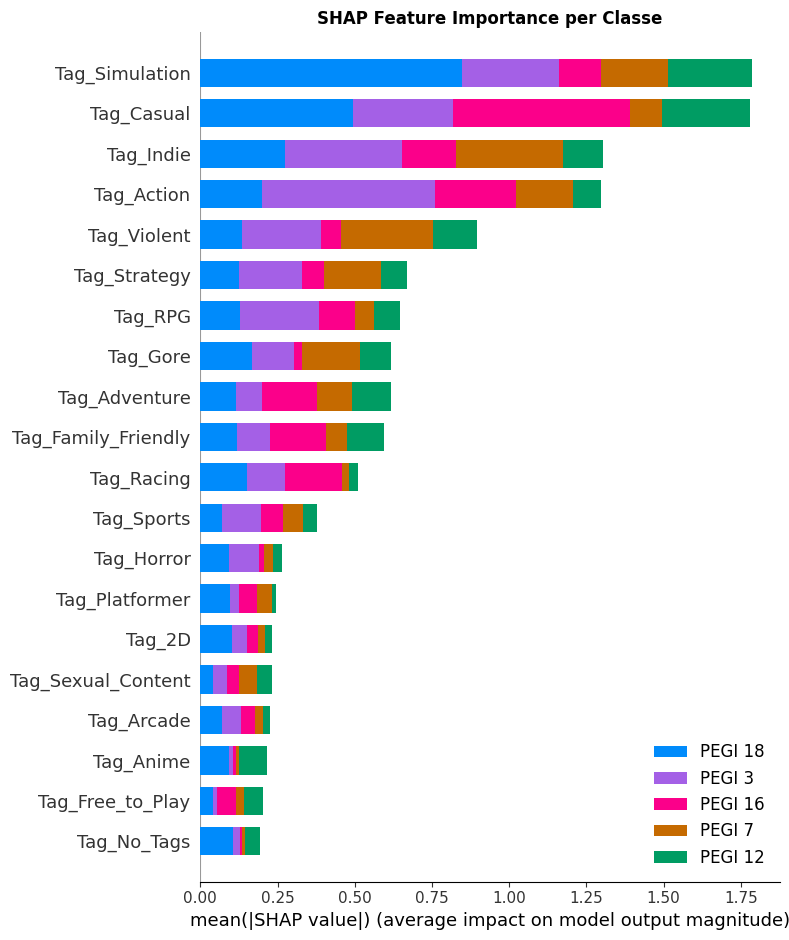

In [20]:
# SHAP Analysis
print('\n6. SHAP VALUE ANALYSIS\n')
explainer = shap.TreeExplainer(stacking_clf.named_estimators_['xgb'])
sample_size = min(300, len(X_sel))
X_sample = X_sel.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  class_names=pegi_labels, show=False)
plt.title('SHAP Feature Importance per Classe', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



5. TOP-25 TAGS IMPORTANCE
            Feature  Importance
     Tag_Simulation    0.035414
         Tag_Casual    0.029417
         Tag_Racing    0.020458
        Tag_No_Tags    0.019984
           Tag_JRPG    0.019607
Tag_Family_Friendly    0.018767
        Tag_Violent    0.017720
   Tag_Free_to_Play    0.015710
       Tag_Gambling    0.015193
 Tag_Sexual_Content    0.015134
        Tag_TrackIR    0.014827
           Tag_Gore    0.014463
         Tag_Trains    0.013581
          Tag_Indie    0.013345
         Tag_Nudity    0.012718
       Tag_Strategy    0.012065
         Tag_Action    0.011764
         Tag_Sports    0.011153
          Tag_Anime    0.009350
    Tag_Escape_Room    0.009235
            Tag_RPG    0.009226
     Tag_Platformer    0.009188
         Tag_Horror    0.008624
          Tag_Voxel    0.008598
        Tag_Vampire    0.008554


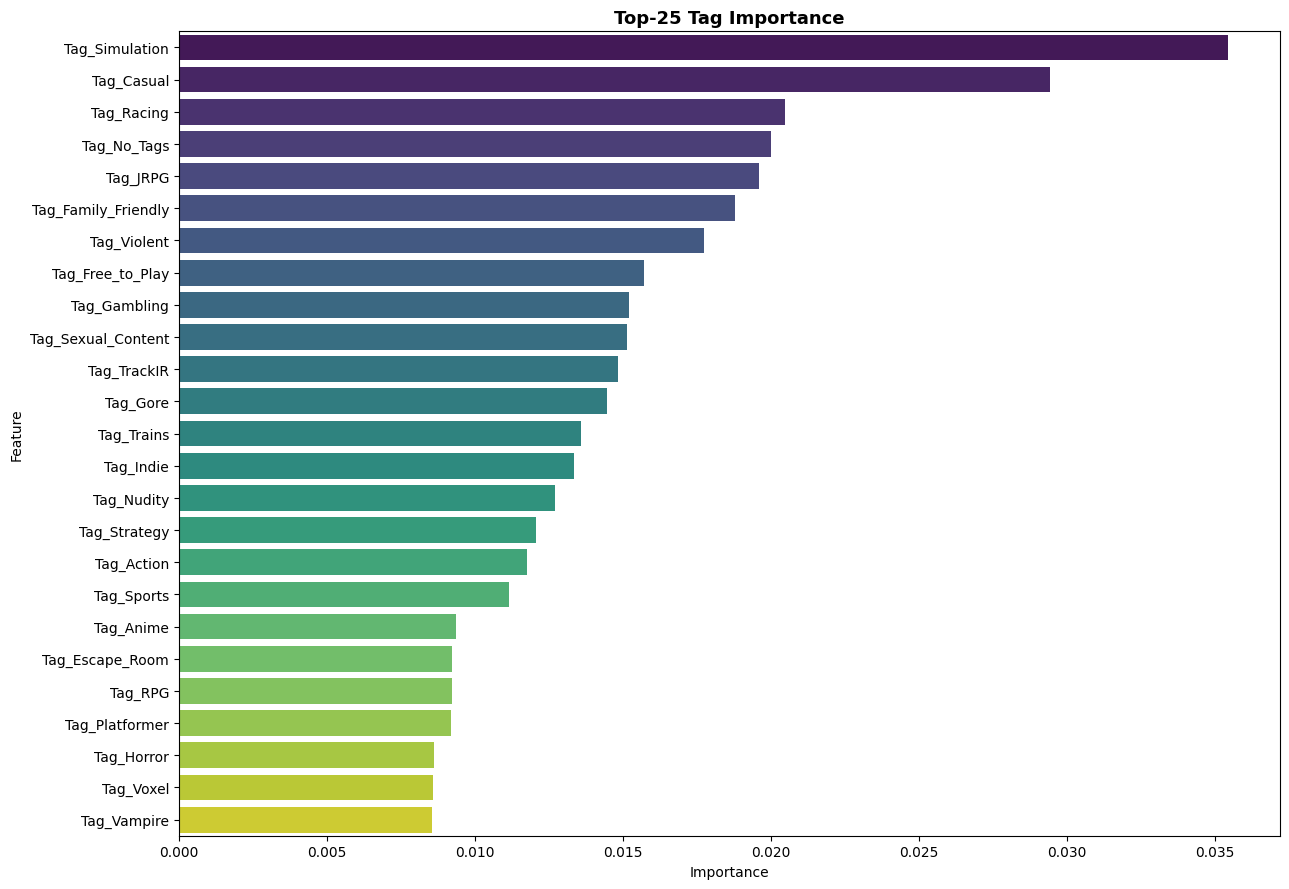

In [21]:
# Top tag importance
imp_scores = stacking_clf.named_estimators_['xgb'].feature_importances_
imp_df = pd.DataFrame({'Feature': sel_names, 'Importance': imp_scores})
imp_df = imp_df.sort_values('Importance', ascending=False)

print('\n5. TOP-25 TAGS IMPORTANCE')
top_n = min(25, len(imp_df))
print(imp_df.head(top_n).to_string(index=False))
plt.figure(figsize=(13, 9))
sns.barplot(data=imp_df.head(top_n), x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title(f'Top-{top_n} Tag Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
